<a href="https://colab.research.google.com/github/chiranjivia567-rgb/ML/blob/main/ml_logistic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


path = kagglehub.dataset_download(
    "vishvaachhatrara/missing-values-pima-indians-diabetes-data"
)

# Use the downloaded path and the correct filename from the dataset
df = pd.read_csv(os.path.join(path, "pima_Missing_values.csv"))

100%|██████████| 8.77k/8.77k [00:00<00:00, 15.3MB/s]

Extracting files...


In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "pima_Missing_values.csv"))
df.info()
df.head()
df.sample(70)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   NoOfPregency       690 non-null    object
 1   PlasmaGlucoseCon   690 non-null    object
 2   BloodPressure      690 non-null    object
 3   SkinFoldThickness  690 non-null    object
 4   Insuline           690 non-null    object
 5   BMI                690 non-null    object
 6   DiabetesPedigree   690 non-null    object
 7   Age                690 non-null    object
 8   Class              690 non-null    object
dtypes: object(9)
memory usage: 48.6+ KB


,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,Insuline,BMI,DiabetesPedigree,Age,Class
400,0,181,88,44,510,43.3,0.222,26,tested_positive
198,1,87,60,37,75,37.2,0.509,<null>,tested_negative
634,7,194,68,28,0,<null>,0.745,41,tested_positive
342,7,133,84,0,0,40.2,0.696,37,tested_negative
397,10,111,70,27,0,27.5,0.141,40,tested_positive
...,...,...,...,...,...,...,...,...,...
246,0,177,60,29,478,34.6,1.072,21,tested_positive
72,5,117,92,<null>,<null>,34.1,<null>,38,tested_negative
257,5,121,72,23,112,26.2,0.245,30,tested_negative
286,0,119,64,18,92,34.9,0.725,<null>,tested_negative


In [ ]:
import numpy as np
import pandas as pd

# Columns where zero is medically impossible
cols_with_invalid_zeros = [
    'PlasmaGlucoseCon',
    'BloodPressure',
    'SkinFoldThickness',
    'Insuline',
    'BMI',
    'Age'
]

#  Replace '<null>' with NaN in the entire dataset
df.replace('<null>', np.nan, inplace=True)

#  Replace zero with NaN ONLY where zero is invalid
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

print(df.isnull().sum())







NoOfPregency         66
PlasmaGlucoseCon     69
BloodPressure        78
SkinFoldThickness    65
Insuline             72
BMI                  66
DiabetesPedigree     75
Age                  61
Class                 0
dtype: int64


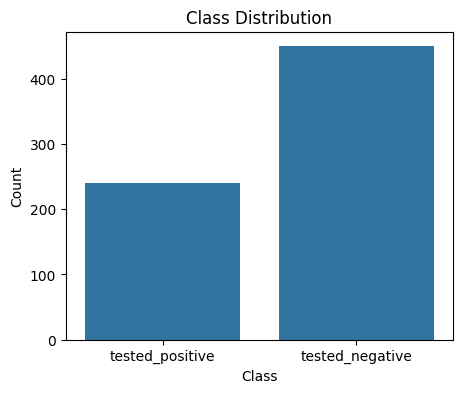

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define y from the 'Class' column of the dataframe
y = df['Class']

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

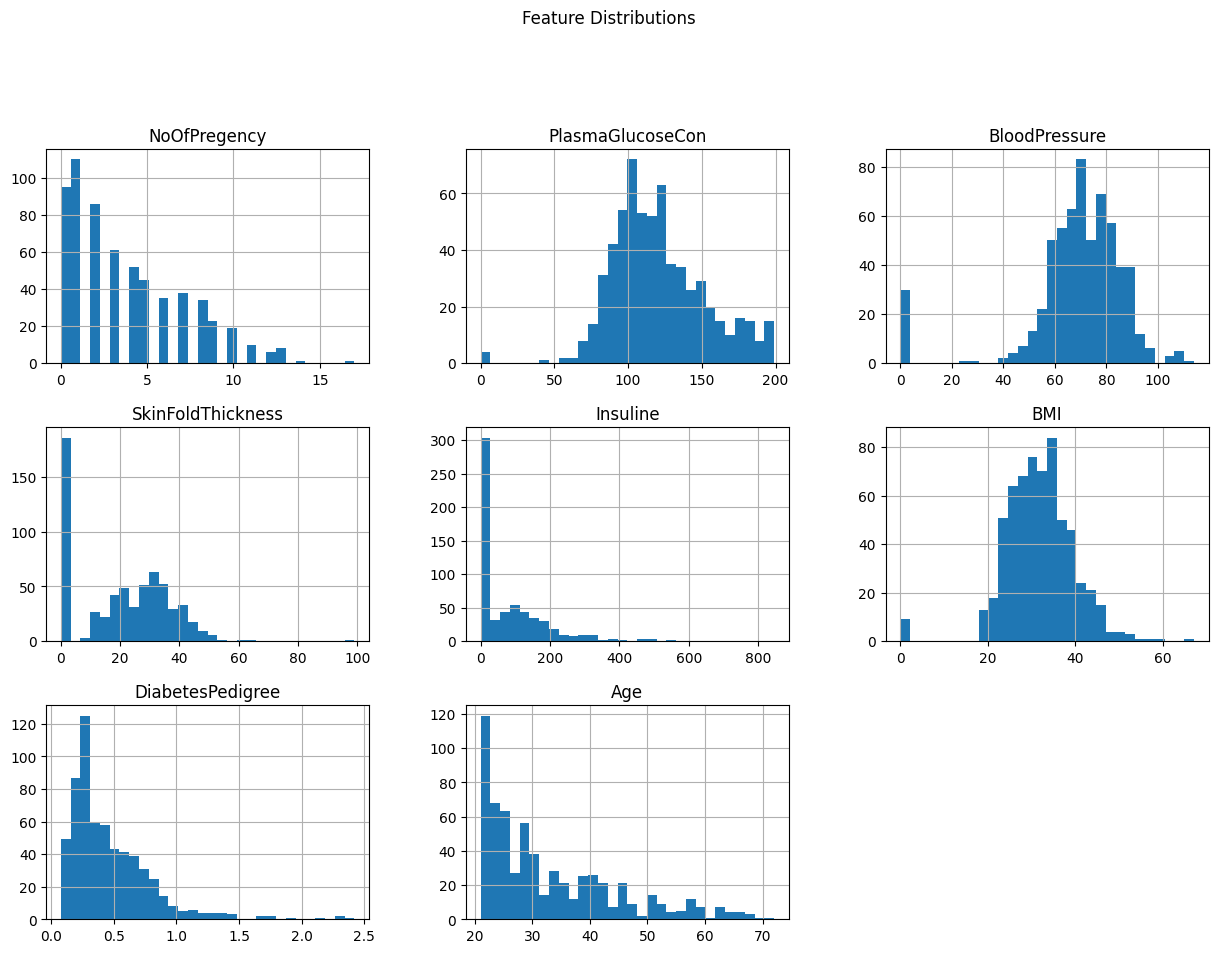

In [ ]:
X = df.drop(columns=['Class'])
X = X.apply(pd.to_numeric, errors='coerce') # Convert columns to numeric
X.hist(figsize=(15,10), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

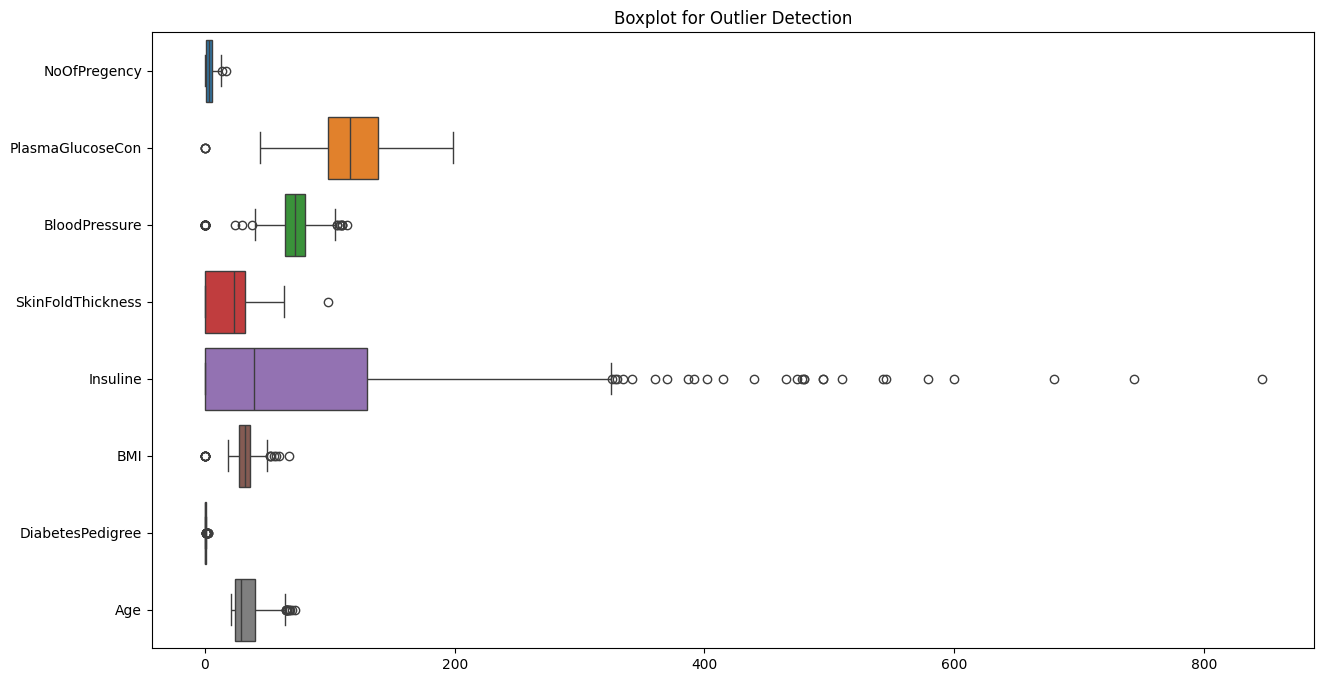

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=X, orient="h")
plt.title("Boxplot for Outlier Detection")
plt.show()


In [ ]:

X = df.drop(columns=['Class'])
y = df['Class']
print(X.shape)
print(y.shape)






(690, 8)
(690,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
y = df['Class'].astype(str).str.strip()
le = LabelEncoder()
y = le.fit_transform(y)
import pandas as pd

print(pd.Series(y).unique())
print(dict(zip(le.classes_, le.transform(le.classes_))))




[1 0]
{'tested_negative': np.int64(0), 'tested_positive': np.int64(1)}


In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NoOfPregency       624 non-null    float64
 1   PlasmaGlucoseCon   621 non-null    float64
 2   BloodPressure      612 non-null    float64
 3   SkinFoldThickness  625 non-null    float64
 4   Insuline           618 non-null    float64
 5   BMI                624 non-null    float64
 6   DiabetesPedigree   615 non-null    float64
 7   Age                629 non-null    float64
dtypes: float64(8)
memory usage: 43.3 KB


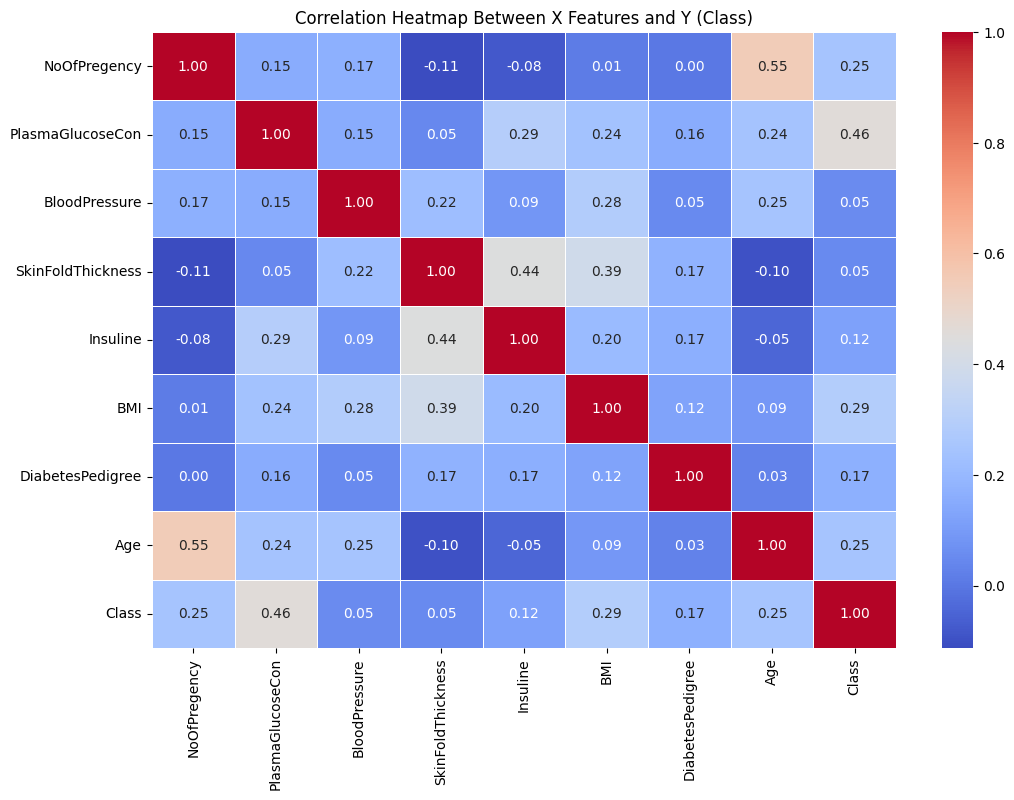

In [ ]:
data = pd.concat([X, pd.Series(y, name='Class')], axis=1)
corr = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap Between X Features and Y (Class)")
plt.show()

In [ ]:

X = X.drop(columns=['Insuline'], errors='ignore')
X.head()

,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,BMI,DiabetesPedigree,Age
0,10.0,108.0,66.0,NaN,32.4,0.272,42.0
1,7.0,107.0,74.0,0.0,29.6,0.254,31.0
2,0.0,179.0,90.0,27.0,NaN,0.686,23.0
3,10.0,125.0,70.0,26.0,31.1,0.205,41.0
4,10.0,NaN,NaN,0.0,38.0,0.537,34.0


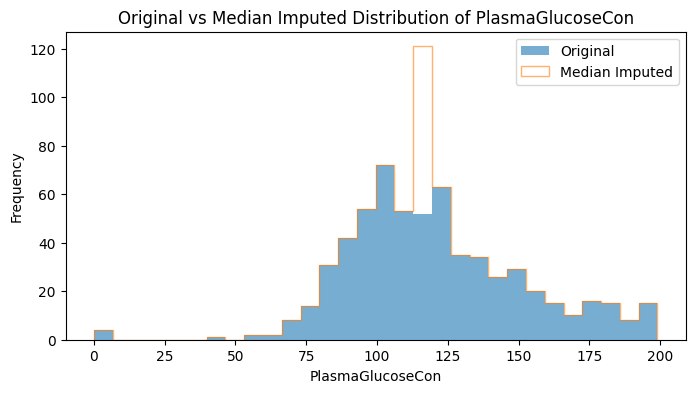

In [ ]:
col = 'PlasmaGlucoseCon'
X_original = X.copy()
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_original),
                         columns=X_original.columns)
plt.figure(figsize=(8,4))

plt.hist(
    X_original[col].dropna(),
    bins=30,
    alpha=0.6,
    label='Original',
    histtype='stepfilled'
)

plt.hist(
    X_imputed[col],
    bins=30,
    alpha=0.6,
    label='Median Imputed',
    histtype='step'
)

plt.title(f'Original vs Median Imputed Distribution of {col}')
plt.xlabel(col)
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
X_original = X.copy()
from sklearn.impute import SimpleImputer
import pandas as pd

median_imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=X.columns
)
X_imputed.isna().sum()


,0
NoOfPregency,0
PlasmaGlucoseCon,0
BloodPressure,0
SkinFoldThickness,0
BMI,0
DiabetesPedigree,0
Age,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (552, 7)
X_test : (138, 7)
y_train: (552,)
y_test : (138,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled  = scaler.transform(X_test)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
# from sklearn.metrics import accuracy_score, roc_auc_score

# # Base model
# log_reg = LogisticRegression(
#     class_weight="balanced",
#     solver="lbfgs",
#     max_iter=2000
# )

# # Hyperparameter grid
# param_grid = {
#     "C": [0.01, 0.1, 0.5, 0.8, 1, 5, 10],
#     "penalty": ["l2"]
# }

# # Grid Search with CV
# grid_search = GridSearchCV(
#     estimator=log_reg,
#     param_grid=param_grid,
#     cv=5,
#     scoring="roc_auc",
#     n_jobs=-1
# )

# grid_search.fit(X_train_scaled, y_train)
# print("Best Parameters:", grid_search.best_params_)
# print("Best CV Score:", grid_search.best_score_)



Training Log Loss: 0.5003754165641138
Testing Log Loss : 0.4574065260201536


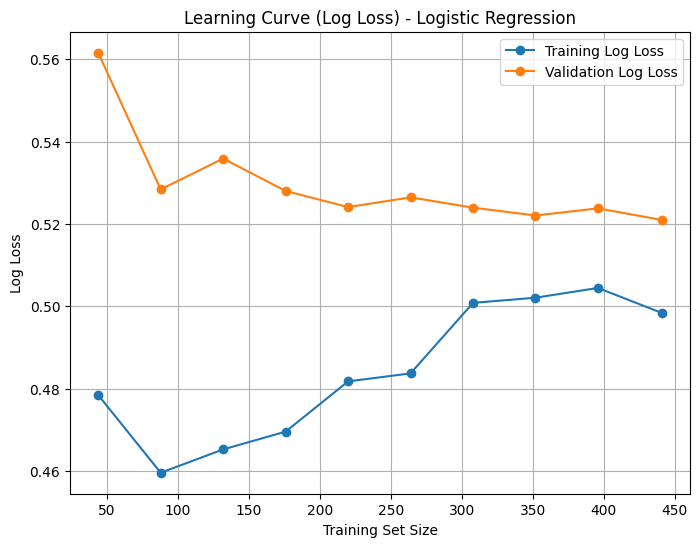

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import log_loss
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
log_reg = LogisticRegression(max_iter=1000)



param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}


grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)



# 1. Best model from GridSearch

best_model = grid_search.best_estimator_


# 2. Train & Test Log Loss

y_train_prob = best_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob  = best_model.predict_proba(X_test_scaled)[:, 1]

train_log_loss = log_loss(y_train, y_train_prob)
test_log_loss  = log_loss(y_test, y_test_prob)

print("Training Log Loss:", train_log_loss)
print("Testing Log Loss :", test_log_loss)


# 3. Learning Curve (Log Loss)

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_log_loss",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert negative log loss to positive
train_loss_mean = -np.mean(train_scores, axis=1)
test_loss_mean  = -np.mean(test_scores, axis=1)


# 4. Plot Training & Validation Log Loss

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_loss_mean, marker='o', label="Training Log Loss")
plt.plot(train_sizes, test_loss_mean, marker='o', label="Validation Log Loss")

plt.xlabel("Training Set Size")
plt.ylabel("Log Loss")
plt.title("Learning Curve (Log Loss) - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
best_model = grid_search.best_estimator_
cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

Cross-Validation ROC-AUC Scores: [0.83618234 0.87820513 0.72331871 0.80409357 0.82346491]
Mean CV ROC-AUC: 0.813052931473984


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy: {accuracy:.5f}")
print(f"Test ROC-AUC: {roc_auc:.5f}")

Test Accuracy: 0.77536
Test ROC-AUC: 0.85278


ROC-AUC: 0.8527777777777777


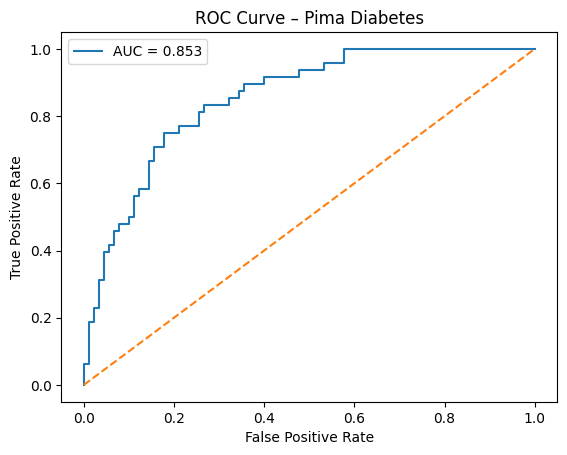

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_score)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pima Diabetes")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
import numpy as np

J = tpr - fpr
best_index = np.argmax(J)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("TPR (Recall):", tpr[best_index])
print("FPR:", fpr[best_index])
y_tuned = (y_prob >= best_threshold).astype(int)





In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Accuracy :", accuracy_score(y_test, y_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_tuned))